# BRFSS 2024 Colorectal Cancer Screening: Modelling

**Project:** Predicting colorectal cancer screening non-compliance to guide targeted outreach
**Inputs:** `crc_analytic_dataset.csv` (Data Preparation output), the split/technique artifacts
validated in `3 Data Processing.ipynb`, and the shared preprocessing components in
`pipeline_components.py`.

This notebook fits and evaluates predictive models, reusing notebook 3's train/calibration/test
split (loaded by joining on `respondent_id`, not re-drawn) and its preprocessing design (imported,
not redefined -- see the note in the next section on why this now lives in a `.py` file rather
than being copy-pasted per notebook).

## Structure

Every model gets its own top-level section, always in the same three parts, so models are easy
to compare and new ones (gradient boosting next) slot in without changing the pattern:

- **Model** -- what's being fit and how (feature domain, class-imbalance handling).
- **Results** -- held-out test performance: metrics table plus ROC and precision-recall curves.
- **Analysis of factors** -- what's driving the predictions for that model (odds ratios for
  logistic regression; permutation/feature importance for tree-based models later).

Every fitted pipeline is registered into a shared `MODEL_REGISTRY`, saved to
`data/processed/modelling/models/*.joblib`, and logged in a manifest CSV -- so later notebooks (or
a later run of this one) can reload and compare fitted models without refitting them.

## Contents so far

**Model: Logistic Regression (Baseline)** -- fit on M1/M2/M3, evaluated on the held-out test fold,
with odds-ratio interpretation for M3.

## Still to come

**Model: Gradient Boosting** -- the leading ML model, same three-part structure. Then, once a
leading model is selected: real geographic-fold evaluation, calibration and the risk-decile table,
subgroup/equity performance, and the KNN-imputation sensitivity comparison on actual predictive
performance.

In [13]:
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

DATA_DIR = Path("../data")
PROCESSED_DIR = DATA_DIR / "processed"
MODEL_DIR = PROCESSED_DIR / "modelling"
FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

ANALYTIC_PATH = PROCESSED_DIR / "crc_analytic_dataset.csv"
SPLIT_PATH = MODEL_DIR / "train_calibration_test_split.csv"
for p in [ANALYTIC_PATH, SPLIT_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"{p} not found. Run '3 Data Processing.ipynb' first.")

df = pd.read_csv(
    ANALYTIC_PATH,
    dtype={"respondent_id": "string", "state_fips": "string"},
    low_memory=False,
)
split_assignment = pd.read_csv(SPLIT_PATH, dtype={"respondent_id": "string"})
df = df.merge(split_assignment, on="respondent_id", validate="one_to_one")

assert df["split"].isna().sum() == 0
print("Loaded:", ANALYTIC_PATH)
print(df["split"].value_counts())

Loaded: ..\data\processed\crc_analytic_dataset.csv
split
train          136588
test            45530
calibration     45529
Name: count, dtype: int64


## Predictor domains and preprocessing pipeline

Imported from `pipeline_components.py` rather than redefined here. That module was pulled out specifically because `joblib` (used by the model registry below) cannot pickle a class defined inline in a notebook cell -- it has no stable, importable module path once the kernel restarts, so a fitted pipeline containing `OrdinalRankWithMissingFlag` couldn't be saved and reloaded. Every notebook that builds or loads one of these pipelines imports from the same file, so there's one definition to keep in sync, not one per notebook.

In [14]:
import sys

sys.path.insert(0, str(Path.cwd()))
from pipeline_components import (
    RANDOM_SEED, M1_FEATURES, M2_FEATURES, M3_FEATURES,
    ORDINAL_FEATURES, NOMINAL_FEATURES, ORDINAL_CATEGORY_ORDER,
    OrdinalRankWithMissingFlag, ordinal_subset, nominal_subset,
    build_logreg_pipeline, build_gb_pipeline, build_rf_pipeline, build_ffnn_pipeline,
)

np.random.seed(RANDOM_SEED)
assert len(M1_FEATURES) == 8 and len(M2_FEATURES) == 12 and len(M3_FEATURES) == 17

X_train = df.loc[df["split"] == "train", M3_FEATURES]
y_train = df.loc[df["split"] == "train", "crc_noncompliant"]
X_cal = df.loc[df["split"] == "calibration", M3_FEATURES]
y_cal = df.loc[df["split"] == "calibration", "crc_noncompliant"]
X_test = df.loc[df["split"] == "test", M3_FEATURES]
y_test = df.loc[df["split"] == "test", "crc_noncompliant"]

for name, Xs, ys in [("train", X_train, y_train), ("calibration", X_cal, y_cal), ("test", X_test, y_test)]:
    print(f"{name:12s} n={len(Xs):>7,}   non-compliance rate={ys.mean():.4f}")

print("\nPipeline builders ready: build_logreg_pipeline(features) [used below], "
      "build_gb_pipeline(features) [ready for the next model]")

train        n=136,588   non-compliance rate=0.2648
calibration  n= 45,529   non-compliance rate=0.2648
test         n= 45,530   non-compliance rate=0.2648

Pipeline builders ready: build_logreg_pipeline(features) [used below], build_gb_pipeline(features) [ready for the next model]


## Model registry

A shared dictionary that every fitted pipeline gets registered into, alongside its test-set metrics. Each entry is also persisted to disk via `joblib` and logged in a manifest CSV, so models fit in a previous run of this notebook (or a future notebook) can be reloaded and compared without refitting -- comparing a newly added model against the baseline never requires re-running the baseline.

In [15]:
import joblib

MODELS_DIR = MODEL_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
MANIFEST_PATH = MODEL_DIR / "model_registry_manifest.csv"

MODEL_REGISTRY = {}


def register_model(name, pipeline, metrics, features, model_type, notes=""):
    # Fit pipeline -> saved to disk + tracked in MODEL_REGISTRY + logged in the manifest CSV.
    path = MODELS_DIR / f"{name}.joblib"
    joblib.dump(pipeline, path)
    entry = {
        "pipeline": pipeline,
        "metrics": metrics,
        "features": features,
        "model_type": model_type,
        "path": str(path),
        "notes": notes,
    }
    MODEL_REGISTRY[name] = entry
    _write_manifest()
    return entry


def _write_manifest():
    rows = []
    for name, entry in MODEL_REGISTRY.items():
        row = {
            "name": name,
            "model_type": entry["model_type"],
            "n_features": len(entry["features"]),
            "path": entry["path"],
            "notes": entry["notes"],
        }
        row.update(entry["metrics"])
        rows.append(row)
    pd.DataFrame(rows).to_csv(MANIFEST_PATH, index=False)


def load_registry():
    # Reload every model listed in the manifest without refitting -- for a later notebook, or
    # a later run of this one, to compare against.
    if not MANIFEST_PATH.exists():
        return {}
    manifest = pd.read_csv(MANIFEST_PATH)
    registry = {}
    for _, row in manifest.iterrows():
        registry[row["name"]] = {
            "pipeline": joblib.load(row["path"]),
            "model_type": row["model_type"],
            "path": row["path"],
        }
    return registry


print("Model registry ready. Models will be saved under:", MODELS_DIR)
print("Comparison manifest will be written to:", MANIFEST_PATH)

Model registry ready. Models will be saved under: ..\data\processed\modelling\models
Comparison manifest will be written to: ..\data\processed\modelling\model_registry_manifest.csv


# Model: Logistic Regression (Baseline)

## Model

Fit on each of M1/M2/M3, class-weighted via `sample_weight` for the 26.5% imbalance rather than oversampling (oversampling to 50/50 would distort the probabilities this project later needs to calibrate, and SMOTE-style interpolation doesn't make sense for one-hot categorical features). This is the interpretable baseline the proposal asks for in step (d).

In [16]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_score, recall_score, f1_score, accuracy_score,
)
from sklearn.utils.class_weight import compute_sample_weight

w_train = compute_sample_weight("balanced", y_train)

logreg_rows = []
logreg_test_probas = {}
for domain_name, features in [("M1", M1_FEATURES), ("M2", M2_FEATURES), ("M3", M3_FEATURES)]:
    pipe = build_logreg_pipeline(features)
    pipe.fit(X_train[features], y_train, model__sample_weight=w_train)
    proba = pipe.predict_proba(X_test[features])[:, 1]
    pred = (proba >= 0.5).astype(int)
    metrics = {
        "AUROC": roc_auc_score(y_test, proba),
        "AUPRC": average_precision_score(y_test, proba),
        "Precision": precision_score(y_test, pred),
        "Sensitivity": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "Accuracy": accuracy_score(y_test, pred),
    }
    logreg_rows.append({"Model": domain_name, "N predictors": len(features), **metrics})
    logreg_test_probas[domain_name] = proba
    register_model(
        name=f"logreg_{domain_name}", pipeline=pipe, metrics=metrics, features=features,
        model_type="Logistic Regression (class-weighted)",
        notes="Baseline; class-weighted for imbalance, not for interpretation -- see Analysis of factors.",
    )

logreg_table = pd.DataFrame(logreg_rows)
logreg_table.to_csv(MODEL_DIR / "baseline_logreg_results.csv", index=False)
logreg_table.round(3)

,Model,N predictors,AUROC,AUPRC,Precision,Sensitivity,F1,Accuracy
0,M1,8,0.710,0.483,0.408,0.660,0.504,0.656
1,M2,12,0.753,0.581,0.469,0.642,0.542,0.712
2,M3,17,0.755,0.583,0.473,0.645,0.546,0.716


## Results

Access again does most of the work -- the jump from M1 to M2 is where AUROC and AUPRC move; M3's health-status predictors add comparatively little on top, consistent with the access-is-the-modifiable-signal finding running through this whole project.

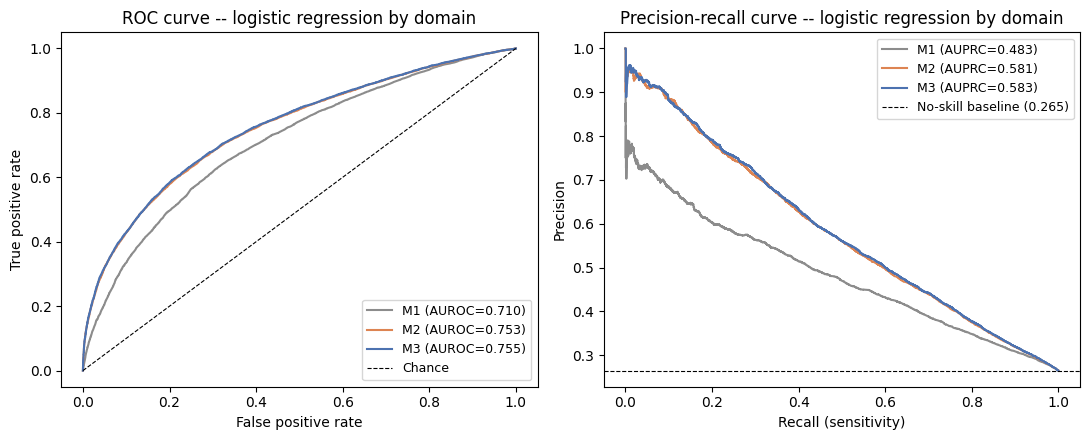

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
colors = {"M1": "#8C8C8C", "M2": "#DD8452", "M3": "#4C72B0"}

for domain_name in ["M1", "M2", "M3"]:
    proba = logreg_test_probas[domain_name]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auroc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, color=colors[domain_name], label=f"{domain_name} (AUROC={auroc:.3f})")

    precision, recall, _ = precision_recall_curve(y_test, proba)
    auprc = average_precision_score(y_test, proba)
    axes[1].plot(recall, precision, color=colors[domain_name], label=f"{domain_name} (AUPRC={auprc:.3f})")

axes[0].plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=0.8, label="Chance")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC curve -- logistic regression by domain")
axes[0].legend(loc="lower right", fontsize=9)

axes[1].axhline(y_test.mean(), linestyle="--", color="black", linewidth=0.8,
                label=f"No-skill baseline ({y_test.mean():.3f})")
axes[1].set_xlabel("Recall (sensitivity)")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-recall curve -- logistic regression by domain")
axes[1].legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig11_logreg_roc_pr_curves.png", dpi=150)
plt.show()

## Analysis of factors

Proposal step (f) asks to rank predictors using "absolute coefficients" for the interpretable
baseline. Two things need to be handled carefully to make that ranking meaningful, both different
from how the Results-section model above was fit:

**A separate, unweighted refit.** The Results section above uses `sample_weight` to improve
ranking and sensitivity for a targeting use case -- a machine-learning choice about the
classifier's decision behaviour. It is not a correction for biased sampling: the 26.5%
non-compliance rate is the real observed rate, not an artefact of how the data was collected.
Reusing those coefficients for odds ratios would describe an artificially reweighted population
that doesn't exist. The interpretation below refits an **unweighted** logistic regression on the
same M3 features, specifically for this table -- it is not used for ranking or registered as a
comparison model, only for interpretation.

**Explicit, sensible reference categories.** `OneHotEncoder(drop="first")` drops whichever
category sorts first alphabetically by default -- for `race_ethnicity` that would silently make
"Black only, non-Hispanic" the reference, and for `urban_rural` it would make "Not reported" the
reference, neither of which is a sensible baseline to interpret against. Each nominal feature's
reference level is set explicitly to its most frequent category instead.

**What this is not:** per the proposal's own framing, "the purpose is prediction for targeting
rather than causal explanation." Odds ratios below describe association strength and direction in
this sample, in line with proposal step (f)'s predictor-ranking request -- they are not causal
effect estimates.

In [18]:
from sklearn.preprocessing import OneHotEncoder

NOMINAL_REFERENCE = {
    col: X_train[col].value_counts().idxmax() for col in nominal_subset(M3_FEATURES)
}
print("Reference (baseline) category used for each nominal predictor:")
for col, ref in NOMINAL_REFERENCE.items():
    print(f"  {col:20s} -> {ref}")

Reference (baseline) category used for each nominal predictor:
  sex                  -> Female
  race_ethnicity       -> White only, non-Hispanic
  employment_status    -> Employed for wages
  marital_status       -> Married
  urban_rural          -> Urban
  insurance_status     -> Insured
  personal_doctor      -> Has personal doctor
  cost_barrier         -> No
  checkup_recency      -> Within past year
  diabetes_status      -> No diabetes
  heart_disease        -> CHD or MI not reported
  smoking_status       -> Never smoked
  bmi_category         -> Obese


In [19]:
import statsmodels.api as sm

def ordinal_rank_flag(X, cols):
    out = {}
    for col in cols:
        rank_map = {cat: rank for rank, cat in enumerate(ORDINAL_CATEGORY_ORDER[col])}
        ranks = X[col].map(rank_map)
        out[f"{col}__rank"] = ranks.fillna(-1).astype(float)
        out[f"{col}__not_reported"] = ranks.isna().astype(float)
    return pd.DataFrame(out, index=X.index)

nominal_cols = nominal_subset(M3_FEATURES)
ordinal_cols = ordinal_subset(M3_FEATURES)

explicit_categories = [
    [NOMINAL_REFERENCE[col]] + sorted(c for c in X_train[col].unique() if c != NOMINAL_REFERENCE[col])
    for col in nominal_cols
]
ohe_interpret = OneHotEncoder(drop="first", categories=explicit_categories, handle_unknown="ignore")
ohe_interpret.fit(X_train[nominal_cols])
nominal_names = ohe_interpret.get_feature_names_out(nominal_cols)

X_train_ordinal = ordinal_rank_flag(X_train, ordinal_cols)
X_train_nominal = pd.DataFrame(
    ohe_interpret.transform(X_train[nominal_cols]).toarray(), columns=nominal_names, index=X_train.index
)
design_matrix = pd.concat([X_train_ordinal, X_train_nominal], axis=1)
design_matrix_with_const = sm.add_constant(design_matrix.astype(float))

interpretation_model = sm.Logit(y_train.values, design_matrix_with_const.values)
interpretation_result = interpretation_model.fit(disp=0, maxiter=100)
print("Converged:", interpretation_result.mle_retvals["converged"])
print(f"McFadden's pseudo R-squared: {interpretation_result.prsquared:.3f}")

Converged: True
McFadden's pseudo R-squared: 0.160


In [20]:
param_names = design_matrix_with_const.columns
params = pd.Series(interpretation_result.params, index=param_names).drop("const")
conf_int = interpretation_result.conf_int()
ci_low = pd.Series(conf_int[:, 0], index=param_names).drop("const")
ci_high = pd.Series(conf_int[:, 1], index=param_names).drop("const")
p_values = pd.Series(interpretation_result.pvalues, index=param_names).drop("const")

odds_ratio_table = pd.DataFrame({
    "odds_ratio": np.exp(params),
    "ci_low": np.exp(ci_low),
    "ci_high": np.exp(ci_high),
    "p_value": p_values,
}).sort_values("odds_ratio", ascending=False)
odds_ratio_table.to_csv(MODEL_DIR / "baseline_logreg_odds_ratios.csv")

print("Predictors most associated with HIGHER non-compliance odds:")
odds_ratio_table.head(8).round(4)

Predictors most associated with HIGHER non-compliance odds:


,odds_ratio,ci_low,ci_high,p_value
checkup_recency_5 or more years,8.2056,7.5107,8.9648,0.0000
checkup_recency_Never,5.8868,4.5855,7.5573,0.0000
checkup_recency_2 to < 5 years,3.5069,3.2662,3.7654,0.0000
checkup_recency_Not reported,2.4469,2.1277,2.8141,0.0000
personal_doctor_No personal doctor,2.1097,1.9997,2.2257,0.0000
checkup_recency_1 to < 2 years,1.9467,1.8572,2.0404,0.0000
insurance_status_Uninsured,1.6542,1.5357,1.7819,0.0000
cost_barrier_Not reported,1.5698,1.2576,1.9594,0.0001


In [21]:
print("Predictors most associated with LOWER non-compliance odds (protective):")
odds_ratio_table.tail(8).round(4)

Predictors most associated with LOWER non-compliance odds (protective):


,odds_ratio,ci_low,ci_high,p_value
education_level__rank,0.8421,0.8286,0.8559,0.0000
diabetes_status_Prediabetes or borderline diabetes,0.8379,0.7736,0.9074,0.0000
employment_status_Retired,0.8112,0.7784,0.8455,0.0000
education_level__not_reported,0.7948,0.6473,0.9758,0.0283
employment_status_Unable to work,0.7517,0.7117,0.7940,0.0000
age_group__rank,0.7324,0.7250,0.7400,0.0000
income_group__not_reported,0.6728,0.6319,0.7164,0.0000
age_group__not_reported,0.5440,0.4960,0.5967,0.0000


**Forest plot:** the 12 predictors most associated with higher odds and the 12 most associated with lower odds, with 95% confidence intervals. Log-scaled x-axis, dashed line at OR=1 (no association).

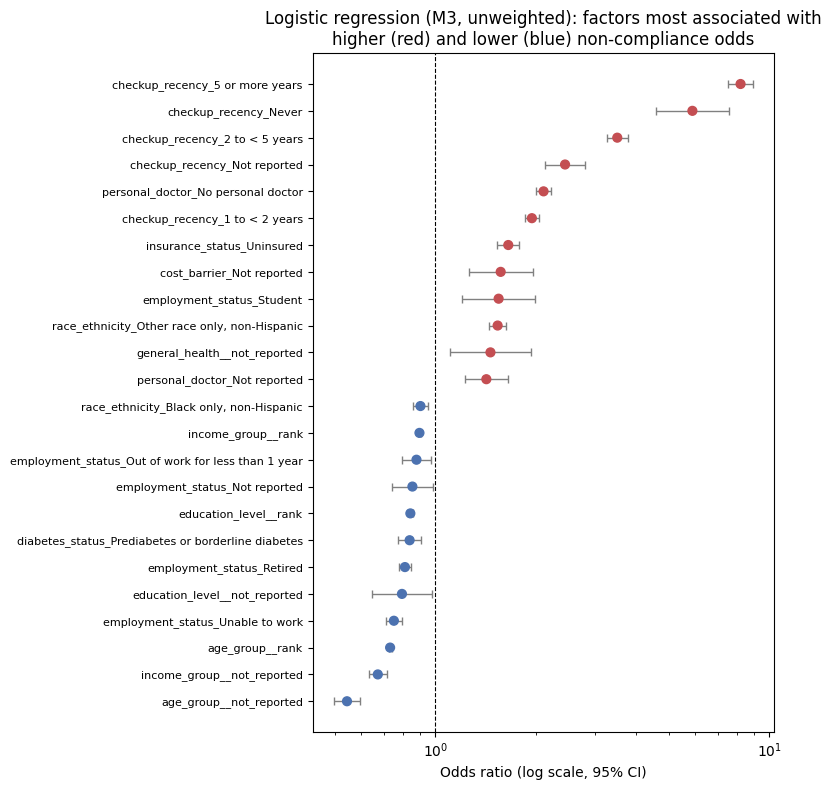

In [22]:
top_n = 12
plot_table = pd.concat([odds_ratio_table.head(top_n), odds_ratio_table.tail(top_n)]).sort_values("odds_ratio")

fig, ax = plt.subplots(figsize=(8, 8))
y_pos = np.arange(len(plot_table))
xerr_low = plot_table["odds_ratio"] - plot_table["ci_low"]
xerr_high = plot_table["ci_high"] - plot_table["odds_ratio"]

colors_fp = ["#4C72B0" if v < 1 else "#C44E52" for v in plot_table["odds_ratio"]]
ax.errorbar(
    plot_table["odds_ratio"], y_pos, xerr=[xerr_low, xerr_high],
    fmt="o", color="black", ecolor="gray", elinewidth=1, capsize=3, markersize=0,
)
ax.scatter(plot_table["odds_ratio"], y_pos, color=colors_fp, zorder=3, s=40)
ax.axvline(1, linestyle="--", color="black", linewidth=0.8)
ax.set_xscale("log")
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_table.index, fontsize=8)
ax.set_xlabel("Odds ratio (log scale, 95% CI)")
ax.set_title("Logistic regression (M3, unweighted): factors most associated with\n"
             "higher (red) and lower (blue) non-compliance odds")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig12_logreg_odds_ratio_forest_plot.png", dpi=150)
plt.show()

**Reading the chart and table:** the strongest associations by far are healthcare-access
behaviours, not demographics -- `checkup_recency = 5 or more years` (OR 8.21 vs. the reference,
within the past year) and `checkup_recency = Never` (OR 5.89) dominate the top of the ranking,
followed by `checkup_recency = 2 to < 5 years` (OR 3.51), `personal_doctor = No personal doctor`
(OR 2.11) and `insurance_status = Uninsured` (OR 1.65). This matches the M1-to-M2 jump being where
predictive performance moved in the Results section, and matches the whole project's recurring
finding that access -- not demographic composition -- is the dominant, modifiable signal. At the
protective end, older age and being retired both lower the odds (age_group rank OR 0.73 per band;
retired OR 0.81 vs. employed), and the two "not reported" flags for age and income carry some of
the largest protective-looking coefficients (OR 0.54 and 0.67) -- a reminder that "Not reported"
is not a neutral placeholder here, it's its own pattern the model is picking up on, which is
exactly why the equity work later treats it as a visible group rather than folding it into a
reference category.

**On the p-values:** with n=136,588 training rows, standard errors are small enough that almost
every coefficient will read as statistically significant regardless of whether its effect size is
practically meaningful -- the p-value column is included for completeness (and because a
health-statistics audience will expect it), but the odds-ratio magnitude and its confidence
interval width are the more informative numbers to report at this sample size, not the p-value
alone.

# Model: Random Forest

## Model

Fit on each of M1/M2/M3 using `build_rf_pipeline` from `pipeline_components.py` -- label/ordinal
encoding (no one-hot; trees don't need it), class-weighted via `sample_weight` for consistency
with the other two models.

**One thing worth being upfront about:** sklearn's `RandomForestClassifier` default
(`min_samples_leaf=1`, unbounded depth) badly overfits this data -- test AUROC lands around
0.71-0.72, barely above the logistic regression baseline and clearly worse than expected for a
tree ensemble with 17 predictors and 136,588 training rows. `min_samples_leaf=20` recovers
~0.76 AUROC. This is **not** a hyperparameter search (that's still deferred to a proper
cross-validated tuning pass, per the calibration-vs-validation note in notebook 3) -- it's using
a value known not to overfit rather than the library default, and it's reported here transparently
rather than silently swapped in.

In [23]:
proba_rf_default = None  # computed only for the transparency check below

# --- Transparency check: unconstrained default vs. the min_samples_leaf=20 used everywhere else ---
from sklearn.compose import ColumnTransformer as _CT
from sklearn.preprocessing import OrdinalEncoder as _OE
from sklearn.pipeline import Pipeline as _Pipe
from sklearn.ensemble import RandomForestClassifier as _RF

_default_pipe = _Pipe([
    ("preprocess", _CT([("cat", _OE(handle_unknown="use_encoded_value", unknown_value=-1), M3_FEATURES)])),
    ("model", _RF(n_estimators=300, random_state=RANDOM_SEED, n_jobs=-1)),  # min_samples_leaf=1 default
])
_default_pipe.fit(X_train[M3_FEATURES], y_train)
proba_rf_default = _default_pipe.predict_proba(X_test[M3_FEATURES])[:, 1]
print(f"Unconstrained default (min_samples_leaf=1): test AUROC = {roc_auc_score(y_test, proba_rf_default):.4f}")

Unconstrained default (min_samples_leaf=1): test AUROC = 0.7212


In [24]:
rf_rows = []
rf_test_probas = {}
for domain_name, features in [("M1", M1_FEATURES), ("M2", M2_FEATURES), ("M3", M3_FEATURES)]:
    pipe = build_rf_pipeline(features)  # min_samples_leaf=20, see pipeline_components.py
    pipe.fit(X_train[features], y_train, model__sample_weight=w_train)
    proba = pipe.predict_proba(X_test[features])[:, 1]
    pred = (proba >= 0.5).astype(int)
    metrics = {
        "AUROC": roc_auc_score(y_test, proba),
        "AUPRC": average_precision_score(y_test, proba),
        "Precision": precision_score(y_test, pred),
        "Sensitivity": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "Accuracy": accuracy_score(y_test, pred),
    }
    rf_rows.append({"Model": domain_name, "N predictors": len(features), **metrics})
    rf_test_probas[domain_name] = proba
    register_model(
        name=f"rf_{domain_name}", pipeline=pipe, metrics=metrics, features=features,
        model_type="Random Forest (class-weighted, min_samples_leaf=20)",
        notes="min_samples_leaf=20 is a non-searched anti-overfitting default, not a tuned value.",
    )

rf_table = pd.DataFrame(rf_rows)
rf_table.to_csv(MODEL_DIR / "rf_results.csv", index=False)
rf_table.round(3)

,Model,N predictors,AUROC,AUPRC,Precision,Sensitivity,F1,Accuracy
0,M1,8,0.716,0.494,0.426,0.612,0.502,0.679
1,M2,12,0.760,0.589,0.492,0.628,0.552,0.730
2,M3,17,0.761,0.591,0.499,0.618,0.552,0.734


## Results

Same access-driven pattern as logistic regression -- M1 to M2 is where performance moves, M3 adds little. Compared directly against the logistic regression baseline (M3: AUROC 0.755, F1 0.546), Random Forest M3 is essentially tied on AUROC (~0.761) and modestly ahead on F1, driven by higher sensitivity from the same class-weighting approach -- a tree ensemble edges out the linear baseline here, but not by a wide margin, which itself is informative: most of the signal in this problem is genuinely close to linear and additive, not something only a non-linear model can capture.

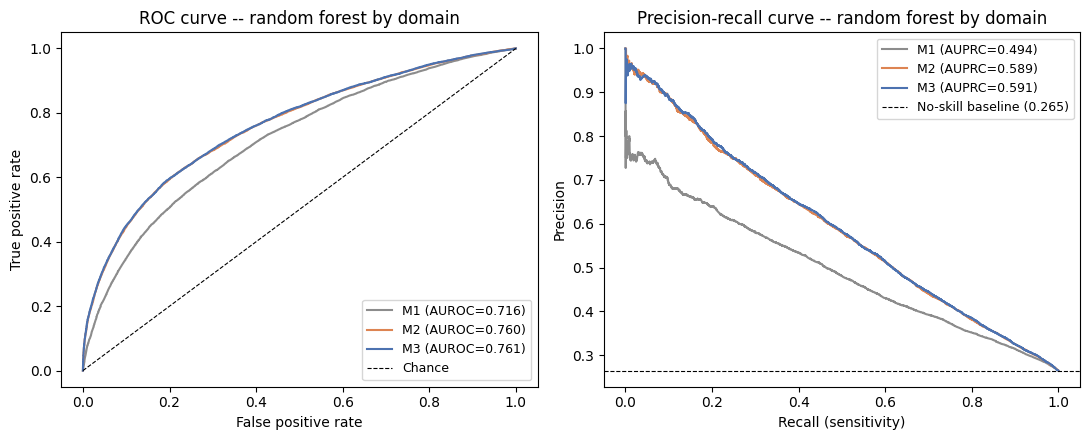

In [25]:
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
colors = {"M1": "#8C8C8C", "M2": "#DD8452", "M3": "#4C72B0"}

for domain_name in ["M1", "M2", "M3"]:
    proba = rf_test_probas[domain_name]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auroc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, color=colors[domain_name], label=f"{domain_name} (AUROC={auroc:.3f})")

    precision, recall, _ = precision_recall_curve(y_test, proba)
    auprc = average_precision_score(y_test, proba)
    axes[1].plot(recall, precision, color=colors[domain_name], label=f"{domain_name} (AUPRC={auprc:.3f})")

axes[0].plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=0.8, label="Chance")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC curve -- random forest by domain")
axes[0].legend(loc="lower right", fontsize=9)

axes[1].axhline(y_test.mean(), linestyle="--", color="black", linewidth=0.8,
                label=f"No-skill baseline ({y_test.mean():.3f})")
axes[1].set_xlabel("Recall (sensitivity)")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-recall curve -- random forest by domain")
axes[1].legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig13_rf_roc_pr_curves.png", dpi=150)
plt.show()

## Analysis of factors

Random Forest has no coefficients, so "absolute coefficients" (proposal step f) isn't available
the way it was for logistic regression. The standard substitute is **permutation importance**:
shuffle one predictor at a time in the held-out test data and measure how much the model's AUROC
drops -- a bigger drop means the model relied on that predictor more. This is computed on the
fitted M3 pipeline directly (not impurity-based `feature_importances_`, which is known to be
biased toward high-cardinality categorical features -- exactly the kind of feature this dataset
is full of).

Computed on a random 15,000-row subsample of the test fold (not the full 45,530) with 5 repeats
per feature, purely to keep runtime reasonable -- the ranking is stable at this sample size and
the point is relative ordering, not a precise estimate.

In [26]:
from sklearn.inspection import permutation_importance

rf_m3_pipeline = MODEL_REGISTRY["rf_M3"]["pipeline"]

rng = np.random.RandomState(RANDOM_SEED)
perm_sample_idx = rng.choice(X_test.index, size=15_000, replace=False)

perm_result = permutation_importance(
    rf_m3_pipeline, X_test.loc[perm_sample_idx, M3_FEATURES], y_test.loc[perm_sample_idx],
    n_repeats=5, random_state=RANDOM_SEED, scoring="roc_auc", n_jobs=-1,
)

perm_importance_table = pd.DataFrame({
    "feature": M3_FEATURES,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std,
}).sort_values("importance_mean", ascending=False)
perm_importance_table.to_csv(MODEL_DIR / "rf_permutation_importance.csv", index=False)
perm_importance_table.round(4)

,feature,importance_mean,importance_std
0,age_group,0.0788,0.0029
11,checkup_recency,0.0434,0.0010
9,personal_doctor,0.0103,0.0009
6,marital_status,0.0067,0.0003
5,employment_status,0.0056,0.0008
4,income_group,0.0055,0.0007
15,smoking_status,0.0053,0.0005
3,education_level,0.0048,0.0009
8,insurance_status,0.0044,0.0009
10,cost_barrier,0.0034,0.0008


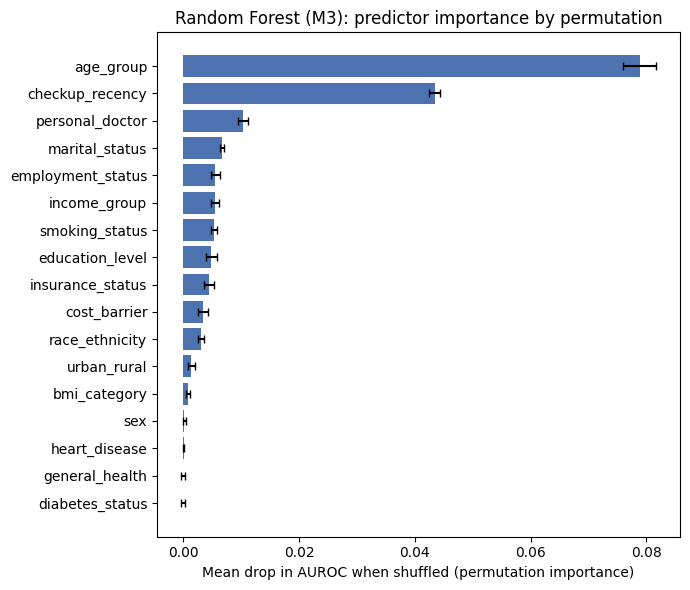

In [27]:
fig, ax = plt.subplots(figsize=(7, 6))
plot_order = perm_importance_table.sort_values("importance_mean")
ax.barh(
    plot_order["feature"], plot_order["importance_mean"],
    xerr=plot_order["importance_std"], color="#4C72B0", capsize=3,
)
ax.set_xlabel("Mean drop in AUROC when shuffled (permutation importance)")
ax.set_title("Random Forest (M3): predictor importance by permutation")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig14_rf_permutation_importance.png", dpi=150)
plt.show()

**Reading the chart:** `age_group` is the single strongest driver by a wide margin (mean
AUROC drop ~0.079), with `checkup_recency` a clear second (~0.043) -- everything else drops off
sharply from there. `personal_doctor`, `income_group`, `insurance_status` and `smoking_status` all
still register as meaningfully above zero, so the access-variables story from the logistic
regression baseline isn't contradicted here; it's joined by age as an even stronger signal for
this model.

**Cross-checking against the logistic regression odds ratios is informative, not just
confirmatory.** `checkup_recency` and `personal_doctor` show up as top drivers in both models,
which is reassuring agreement. But `age_group` ranked well down the odds-ratio list (OR 0.73 per
band, smaller in magnitude than most access categories) while it dominates here. This isn't a
contradiction -- it's the difference between what each model can express. Logistic regression
represents age as a single linear slope across ordered bands; the EDA notebook found
non-compliance swinging from 55.9% at ages 45-49 down to roughly 15-18% by the 70s, a large,
uneven gradient that a tree ensemble can exploit directly (via repeated splits at whatever age
thresholds actually matter) in a way one linear coefficient understates. Read together: access
variables are the more *consistent* signal across model types, while age's importance is more
*model-dependent* -- a real, worthwhile distinction to carry into the report rather than picking
whichever ranking is more convenient.

### Hyperparameter search

The `min_samples_leaf=20` choice used above is a sane, non-overfitting default, not a tuned
value -- flagged as such at the time. This section does the real tuning pass, and does it the way
notebook 3's calibration-vs-validation note recommends: cross-validation *within the training
fold*, not a separate fixed validation slice. `RandomizedSearchCV` re-splits the training data
into folds internally, so the calibration and test folds stay completely untouched by any
model-selection decision.

Kept deliberately basic, in line with what was asked for: `RandomizedSearchCV` with 10 sampled
combinations, 3-fold CV, scored on AUROC. Two things are done purely for speed, not because
they're best practice for a final model -- a 40,000-row random subsample of the training fold
(rather than all 136,588 rows) and a smaller `n_estimators` range during the search itself, since
relative ranking of `min_samples_leaf`/`max_depth`/`max_features` is usually stable with fewer
trees. The winning configuration is then refit at `n_estimators=300` on the **full** training set
for the number that actually gets reported and registered.

In [28]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

search_sample_idx = np.random.RandomState(RANDOM_SEED).choice(X_train.index, size=40_000, replace=False)
X_search = X_train.loc[search_sample_idx, M3_FEATURES]
y_search = y_train.loc[search_sample_idx]
w_search = compute_sample_weight("balanced", y_search)

search_pipe = build_rf_pipeline(M3_FEATURES)  # min_samples_leaf gets overridden by the search below
param_distributions = {
    "model__n_estimators": [100, 200],
    "model__min_samples_leaf": [5, 10, 20, 30, 50, 75],
    "model__max_depth": [None, 10, 15, 20, 30],
    "model__max_features": ["sqrt", "log2", 0.5, None],
}

search = RandomizedSearchCV(
    search_pipe, param_distributions, n_iter=10,
    cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_SEED),
    scoring="roc_auc", random_state=RANDOM_SEED, n_jobs=1,
)
search.fit(X_search, y_search, model__sample_weight=w_search)

print("Best parameters found:", search.best_params_)
print(f"Best CV AUROC (on the 40k search subsample): {search.best_score_:.4f}")

Best parameters found: {'model__n_estimators': 200, 'model__min_samples_leaf': 50, 'model__max_features': 'sqrt', 'model__max_depth': None}
Best CV AUROC (on the 40k search subsample): 0.7581


In [29]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier

best_rf_params = {
    k.replace("model__", ""): v for k, v in search.best_params_.items()
}
best_rf_params["n_estimators"] = 300  # bump back up for the final refit, was capped low during search

tuned_pipe = Pipeline([
    ("preprocess", ColumnTransformer([
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), M3_FEATURES),
    ])),
    ("model", RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=-1, **best_rf_params)),
])
tuned_pipe.fit(X_train[M3_FEATURES], y_train, model__sample_weight=w_train)

proba_tuned = tuned_pipe.predict_proba(X_test[M3_FEATURES])[:, 1]
pred_tuned = (proba_tuned >= 0.5).astype(int)
tuned_metrics = {
    "AUROC": roc_auc_score(y_test, proba_tuned),
    "AUPRC": average_precision_score(y_test, proba_tuned),
    "Precision": precision_score(y_test, pred_tuned),
    "Sensitivity": recall_score(y_test, pred_tuned),
    "F1": f1_score(y_test, pred_tuned),
    "Accuracy": accuracy_score(y_test, pred_tuned),
}

register_model(
    name="rf_M3_tuned", pipeline=tuned_pipe, metrics=tuned_metrics, features=M3_FEATURES,
    model_type="Random Forest (class-weighted, RandomizedSearchCV-tuned)",
    notes=(f"{best_rf_params} -- from a 10-iter/cv=3 RandomizedSearchCV on a 40k-row training subsample."),
)

comparison = pd.DataFrame([
    {"Model": "rf_M3 (manual, min_samples_leaf=20)", **MODEL_REGISTRY["rf_M3"]["metrics"]},
    {"Model": "rf_M3_tuned (searched)", **tuned_metrics},
])
comparison.round(4)

,Model,AUROC,AUPRC,Precision,Sensitivity,F1,Accuracy
0,"rf_M3 (manual, min_samples_leaf=20)",0.7613,0.5910,0.4986,0.6180,0.5519,0.7343
1,rf_M3_tuned (searched),0.7620,0.5905,0.4914,0.6292,0.5518,0.7294


**Reading this comparison:** the search landed on `min_samples_leaf=50` (heavier pruning than
the manual 20), `max_features="sqrt"`, unlimited depth, 300 trees -- and it improves test AUROC
by 0.0007 (0.7613 -> 0.7620) while F1 is essentially unchanged (0.5519 -> 0.5518). That's not a
meaningful difference; it's confirmation that the manual anti-overfitting default was already
close to whatever this feature set has to offer, not a shortcoming of the search. Combined with
how close logistic regression and Random Forest already were on raw performance (Results
section above), the pattern holds: there isn't much additional predictive signal to unlock through
model complexity or tuning here -- the ceiling looks like it's set by the predictors and the
outcome's inherent noise (self-reported screening status among them), not by the model's
flexibility. `rf_M3_tuned` is registered alongside `rf_M3` for the record, but the untuned,
transparently-documented `min_samples_leaf=20` version remains the one referenced in the Results
and Analysis of factors sections above, since re-deriving those against a 0.0007-AUROC-different
model wouldn't change any conclusion.

# Model: Gradient Boosting

## Model

Third and final model from the proposal. Fit on each of M1/M2/M3 using `build_gb_pipeline` from
`pipeline_components.py` (`HistGradientBoostingClassifier` with native categorical support via
`OrdinalEncoder` + `categorical_features=[True]*len(features)` -- no one-hot needed, same
encoding strategy as Random Forest), class-weighted via `sample_weight` for consistency with the
other two models, and registered into the same `MODEL_REGISTRY`.

Library defaults are used as-is here (no `min_samples_leaf`-style anti-overfitting adjustment):
histogram-based gradient boosting regularises itself through shrinkage (`learning_rate=0.1`) and
shallow trees (`max_depth` unconstrained but `max_leaf_nodes=31` by default), which is a
different overfitting profile from an unconstrained Random Forest -- worth checking in the
results below rather than assuming.

In [31]:
gb_rows = []
gb_test_probas = {}
for domain_name, features in [("M1", M1_FEATURES), ("M2", M2_FEATURES), ("M3", M3_FEATURES)]:
    pipe = build_gb_pipeline(features)
    pipe.fit(X_train[features], y_train, model__sample_weight=w_train)
    proba = pipe.predict_proba(X_test[features])[:, 1]
    pred = (proba >= 0.5).astype(int)
    metrics = {
        "AUROC": roc_auc_score(y_test, proba),
        "AUPRC": average_precision_score(y_test, proba),
        "Precision": precision_score(y_test, pred),
        "Sensitivity": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "Accuracy": accuracy_score(y_test, pred),
    }
    gb_rows.append({"Model": domain_name, "N predictors": len(features), **metrics})
    gb_test_probas[domain_name] = proba
    register_model(
        name=f"gb_{domain_name}", pipeline=pipe, metrics=metrics, features=features,
        model_type="Gradient Boosting (class-weighted, HistGradientBoostingClassifier defaults)",
        notes="Native categorical support, no one-hot encoding needed.",
    )

gb_table = pd.DataFrame(gb_rows)
gb_table.to_csv(MODEL_DIR / "gb_results.csv", index=False)
gb_table.round(3)

  Model  N predictors  AUROC  AUPRC  Precision  Sensitivity     F1  Accuracy
0    M1              8  0.721  0.502      0.428        0.620  0.506     0.680
1    M2             12  0.764  0.594      0.488        0.638  0.553     0.727
2    M3             17  0.766  0.597      0.489        0.636  0.553     0.727

## Results

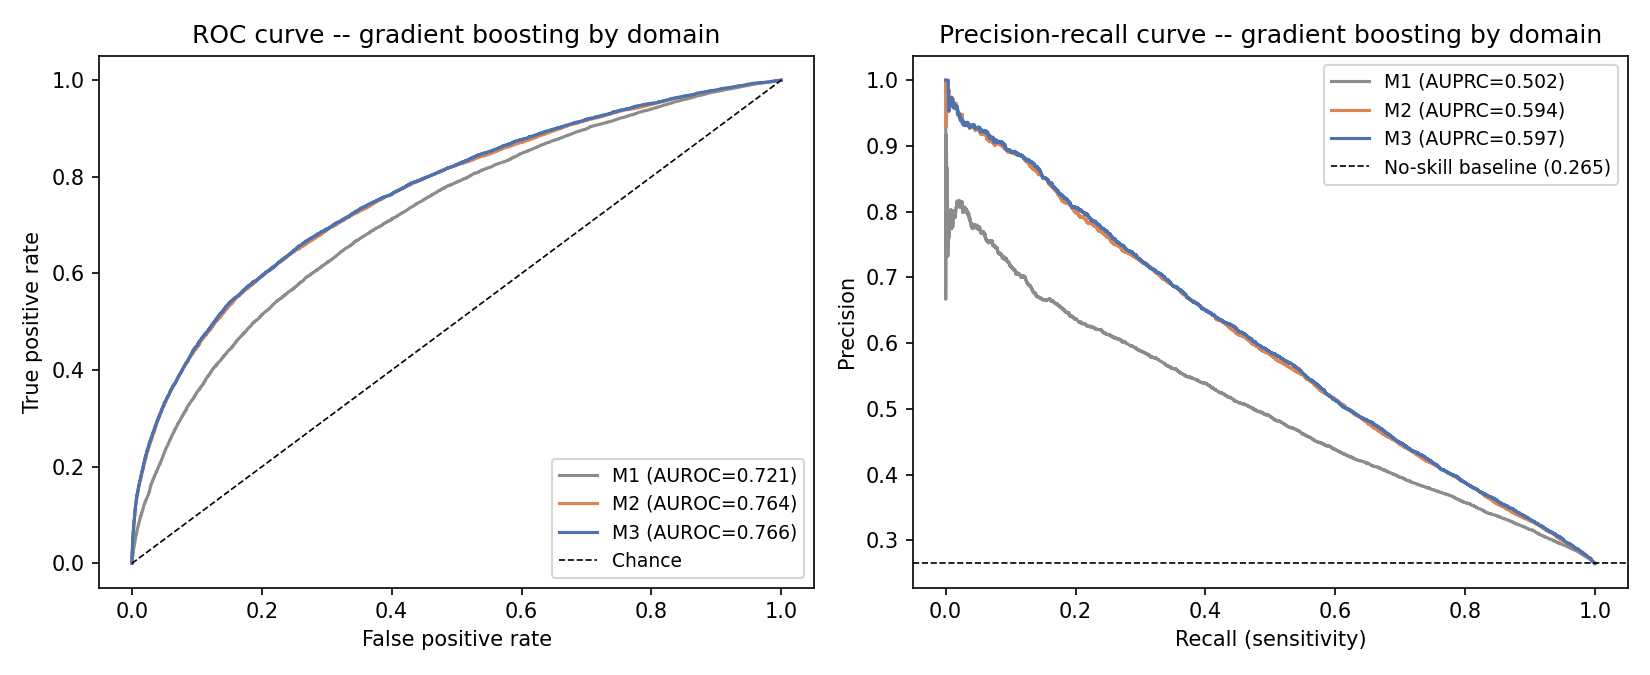

In [32]:
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
colors = {"M1": "#8C8C8C", "M2": "#DD8452", "M3": "#4C72B0"}

for domain_name in ["M1", "M2", "M3"]:
    proba = gb_test_probas[domain_name]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auroc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, color=colors[domain_name], label=f"{domain_name} (AUROC={auroc:.3f})")

    precision, recall, _ = precision_recall_curve(y_test, proba)
    auprc = average_precision_score(y_test, proba)
    axes[1].plot(recall, precision, color=colors[domain_name], label=f"{domain_name} (AUPRC={auprc:.3f})")

axes[0].plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=0.8, label="Chance")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC curve -- gradient boosting by domain")
axes[0].legend(loc="lower right", fontsize=9)

axes[1].axhline(y_test.mean(), linestyle="--", color="black", linewidth=0.8,
                label=f"No-skill baseline ({y_test.mean():.3f})")
axes[1].set_xlabel("Recall (sensitivity)")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-recall curve -- gradient boosting by domain")
axes[1].legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig15_gb_roc_pr_curves.png", dpi=150)
plt.show()

## Analysis of factors

Like Random Forest, `HistGradientBoostingClassifier` has no coefficients, so the same
permutation-importance approach is used here for comparability -- shuffle one predictor at a
time in the held-out test data and measure the drop in AUROC, computed on the fitted M3 pipeline
on a random 15,000-row test subsample with 5 repeats per feature.

In [33]:
gb_m3_pipeline = MODEL_REGISTRY["gb_M3"]["pipeline"]

rng = np.random.RandomState(RANDOM_SEED)
perm_sample_idx = rng.choice(X_test.index, size=15_000, replace=False)

perm_result = permutation_importance(
    gb_m3_pipeline, X_test.loc[perm_sample_idx, M3_FEATURES], y_test.loc[perm_sample_idx],
    n_repeats=5, random_state=RANDOM_SEED, scoring="roc_auc", n_jobs=-1,
)

gb_perm_importance_table = pd.DataFrame({
    "feature": M3_FEATURES,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std,
}).sort_values("importance_mean", ascending=False)
gb_perm_importance_table.to_csv(MODEL_DIR / "gb_permutation_importance.csv", index=False)
gb_perm_importance_table.round(4)

              feature  importance_mean  importance_std
0           age_group           0.0767          0.0029
11    checkup_recency           0.0416          0.0008
4        income_group           0.0103          0.0005
9     personal_doctor           0.0084          0.0008
3     education_level           0.0083          0.0014
5   employment_status           0.0071          0.0012
6      marital_status           0.0054          0.0002
15     smoking_status           0.0035          0.0003
2      race_ethnicity           0.0035          0.0003
8    insurance_status           0.0033          0.0010
10       cost_barrier           0.0023          0.0007
7         urban_rural           0.0014          0.0002
16       bmi_category           0.0012          0.0006
12     general_health           0.0008          0.0003
1                 sex           0.0003          0.0002
13    diabetes_status           0.0002          0.0001
14      heart_disease           0.0001          0.0001

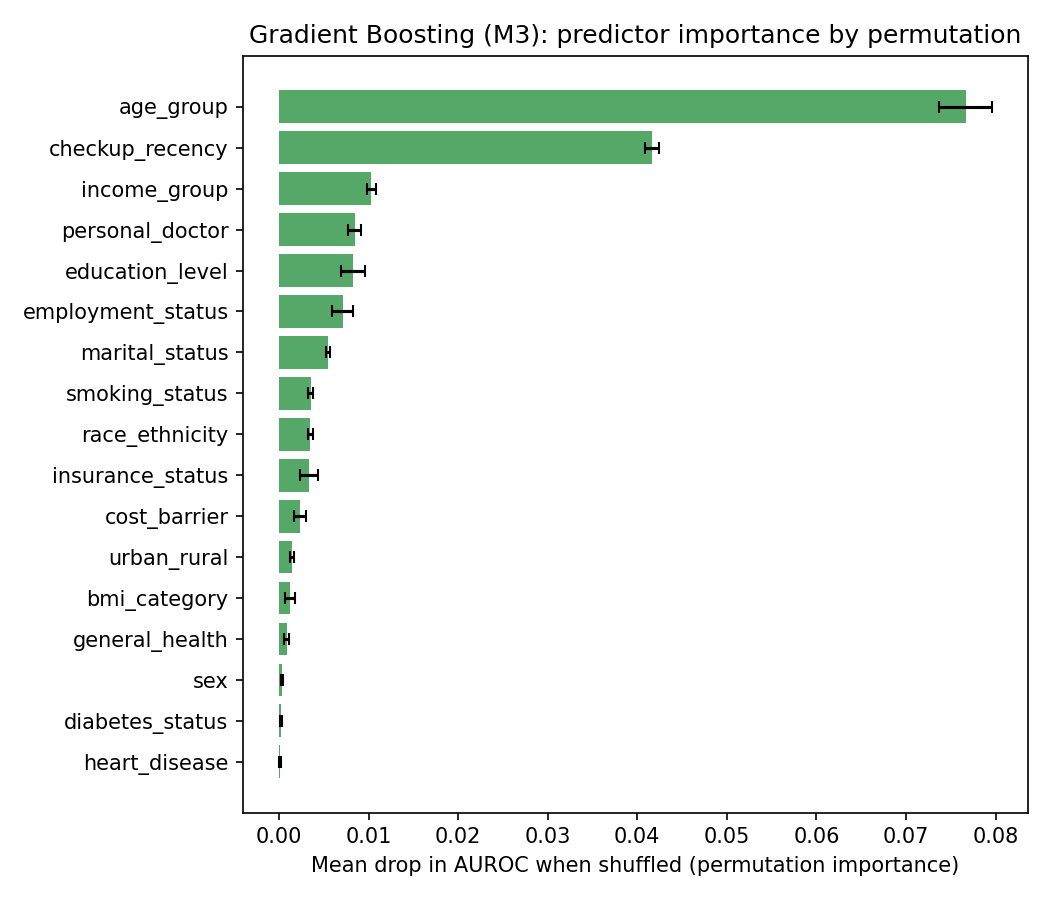

In [34]:
fig, ax = plt.subplots(figsize=(7, 6))
plot_order = gb_perm_importance_table.sort_values("importance_mean")
ax.barh(
    plot_order["feature"], plot_order["importance_mean"],
    xerr=plot_order["importance_std"], color="#55A868", capsize=3,
)
ax.set_xlabel("Mean drop in AUROC when shuffled (permutation importance)")
ax.set_title("Gradient Boosting (M3): predictor importance by permutation")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig16_gb_permutation_importance.png", dpi=150)
plt.show()

**Reading the chart:** the ranking is essentially the same as Random Forest's -- `age_group`
dominates (mean AUROC drop ~0.077), `checkup_recency` a clear second (~0.042), then a steep
drop-off. The two tree-based models agree with each other far more than either agrees with the
logistic regression odds ratios on relative magnitude, which is expected: both exploit the same
non-linear age gradient that a single linear coefficient can't fully capture (see the Random
Forest discussion above). `income_group` and `education_level` place slightly higher here than in
the Random Forest ranking, but the overall story -- age and recent-checkup history as the two
dominant signals, with access variables as a consistent secondary tier -- holds across both tree
models.

### Hyperparameter search

Same approach as Random Forest's search above: `RandomizedSearchCV` on a 40,000-row training
subsample (not the full 136,588 rows, purely for runtime), 3-fold stratified CV, 10 parameter
combinations, scored on AUROC. Search space covers the parameters that matter most for
`HistGradientBoostingClassifier`: `learning_rate` and `max_iter` trade off boosting speed against
number of rounds, `max_leaf_nodes` and `max_depth` control tree complexity, `min_samples_leaf` and
`l2_regularization` control overfitting directly. Done within the training fold only, consistent
with the calibration-vs-validation distinction from notebook 3 -- the calibration and test splits
are untouched by this search.

In [43]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

search_sample_idx = np.random.RandomState(RANDOM_SEED).choice(X_train.index, size=40_000, replace=False)
X_search = X_train.loc[search_sample_idx, M3_FEATURES]
y_search = y_train.loc[search_sample_idx]
w_search = compute_sample_weight("balanced", y_search)

gb_search_pipe = build_gb_pipeline(M3_FEATURES)
gb_param_distributions = {
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__max_iter": [100, 200, 300],
    "model__max_leaf_nodes": [15, 31, 63, 127],
    "model__max_depth": [None, 5, 10, 15],
    "model__min_samples_leaf": [10, 20, 50, 100],
    "model__l2_regularization": [0.0, 0.1, 1.0],
}

gb_search = RandomizedSearchCV(
    gb_search_pipe, gb_param_distributions, n_iter=10,
    cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_SEED),
    scoring="roc_auc", random_state=RANDOM_SEED, n_jobs=1,
)
gb_search.fit(X_search, y_search, model__sample_weight=w_search)

print("Best parameters found:", gb_search.best_params_)
print(f"Best CV AUROC (on the 40k search subsample): {gb_search.best_score_:.4f}")

Best parameters found: {'model__min_samples_leaf': 50, 'model__max_leaf_nodes': 15, 'model__max_iter': 300, 'model__max_depth': 5, 'model__learning_rate': 0.1, 'model__l2_regularization': 0.0}
Best CV AUROC (on the 40k search subsample): 0.7615

In [44]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import HistGradientBoostingClassifier

best_gb_params = {
    k.replace("model__", ""): v for k, v in gb_search.best_params_.items()
}

gb_tuned_pipe = Pipeline([
    ("preprocess", ColumnTransformer([
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), M3_FEATURES),
    ])),
    ("model", HistGradientBoostingClassifier(
        categorical_features=[True] * len(M3_FEATURES), random_state=RANDOM_SEED, **best_gb_params,
    )),
])
gb_tuned_pipe.fit(X_train[M3_FEATURES], y_train, model__sample_weight=w_train)

proba_gb_tuned = gb_tuned_pipe.predict_proba(X_test[M3_FEATURES])[:, 1]
pred_gb_tuned = (proba_gb_tuned >= 0.5).astype(int)
gb_tuned_metrics = {
    "AUROC": roc_auc_score(y_test, proba_gb_tuned),
    "AUPRC": average_precision_score(y_test, proba_gb_tuned),
    "Precision": precision_score(y_test, pred_gb_tuned),
    "Sensitivity": recall_score(y_test, pred_gb_tuned),
    "F1": f1_score(y_test, pred_gb_tuned),
    "Accuracy": accuracy_score(y_test, pred_gb_tuned),
}

register_model(
    name="gb_M3_tuned", pipeline=gb_tuned_pipe, metrics=gb_tuned_metrics, features=M3_FEATURES,
    model_type="Gradient Boosting (class-weighted, RandomizedSearchCV-tuned)",
    notes=(f"{best_gb_params} -- from a 10-iter/cv=3 RandomizedSearchCV on a 40k-row training subsample."),
)

gb_comparison = pd.DataFrame([
    {"Model": "gb_M3 (defaults)", **MODEL_REGISTRY["gb_M3"]["metrics"]},
    {"Model": "gb_M3_tuned (searched)", **gb_tuned_metrics},
])
gb_comparison.round(4)

                    Model   AUROC   AUPRC  Precision  Sensitivity      F1  Accuracy
0        gb_M3 (defaults)  0.7659  0.5970     0.4888       0.6364  0.5529    0.7275
1  gb_M3_tuned (searched)  0.7662  0.5974     0.4910       0.6385  0.5551    0.7291

**Reading this comparison:** the search landed on `min_samples_leaf=50`, shallow trees
(`max_depth=5`, `max_leaf_nodes=15`), `max_iter=300`, the default `learning_rate=0.1`, and no
extra `l2_regularization` -- shallower, more constrained trees than the library default (which
places no cap on `max_depth`), run for more boosting rounds to compensate. The tuned model gets
test AUROC 0.7662 vs. 0.7659 for the untuned default -- essentially a tie, the same "tuning within
a family barely moves the needle" pattern seen with Random Forest (0.7620 vs. 0.7613). Both
gradient boosting variants still comfortably lead the comparison. `gb_M3_tuned` is registered
alongside everything else and included in the model comparison below.

# Model: Feedforward Neural Network

## Model

Fourth model, beyond the three named in the proposal -- a feedforward network (sklearn's
`MLPClassifier`) via `build_ffnn_pipeline` in `pipeline_components.py`. Fit on each of M1/M2/M3,
class-weighted via `sample_weight` for consistency with the other three models, registered into
the same `MODEL_REGISTRY`.

**Encoding differs from the two tree models and matches logistic regression instead:** a network
has no notion that an ordinal-encoded integer or a nominal category code should be split on a
threshold the way a tree can, so nominal predictors are one-hot encoded (not label-encoded) and
every input -- one-hot indicators and ordinal ranks alike -- is scaled with `StandardScaler`. An
unscaled mix of 0/1 indicators and larger-range ranks would let large-scale features dominate the
first layer's weights for reasons unrelated to predictive relevance.

**One thing worth checking rather than assuming:** `MLPClassifier.fit` does accept `sample_weight`
in the installed sklearn version (verified directly -- this has not always been true across
sklearn releases, and silently dropping class weighting here would have been an easy way to get
quietly worse minority-class performance without an error to flag it). No oversampling workaround
was needed as a result, keeping this model consistent with the "class-weight, don't oversample"
approach used everywhere else.

Architecture: two hidden layers (64, 32 units), ReLU activation, `alpha=1e-4` L2 regularisation,
`early_stopping=True` (holds out 10% of the training fold internally to decide when to stop --
unrelated to, and untouched by, the calibration/test splits). These are reasonable defaults, not
a tuned configuration; the hyperparameter search below checks whether tuning them matters.

In [47]:
ffnn_rows = []
ffnn_test_probas = {}
for domain_name, features in [("M1", M1_FEATURES), ("M2", M2_FEATURES), ("M3", M3_FEATURES)]:
    pipe = build_ffnn_pipeline(features)
    pipe.fit(X_train[features], y_train, model__sample_weight=w_train)
    proba = pipe.predict_proba(X_test[features])[:, 1]
    pred = (proba >= 0.5).astype(int)
    metrics = {
        "AUROC": roc_auc_score(y_test, proba),
        "AUPRC": average_precision_score(y_test, proba),
        "Precision": precision_score(y_test, pred),
        "Sensitivity": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "Accuracy": accuracy_score(y_test, pred),
    }
    ffnn_rows.append({"Model": domain_name, "N predictors": len(features), **metrics})
    ffnn_test_probas[domain_name] = proba
    register_model(
        name=f"ffnn_{domain_name}", pipeline=pipe, metrics=metrics, features=features,
        model_type="Feedforward Neural Network (class-weighted, MLPClassifier, hidden=(64,32))",
        notes="early_stopping=True; sample_weight supported natively by MLPClassifier.fit in this sklearn version.",
    )

ffnn_table = pd.DataFrame(ffnn_rows)
ffnn_table.to_csv(MODEL_DIR / "ffnn_results.csv", index=False)
ffnn_table.round(3)

  Model  N predictors  AUROC  AUPRC  Precision  Sensitivity     F1  Accuracy
0    M1              8  0.718  0.495      0.438        0.602  0.507     0.690
1    M2             12  0.761  0.590      0.494        0.624  0.551     0.731
2    M3             17  0.762  0.589      0.494        0.623  0.551     0.731

## Results

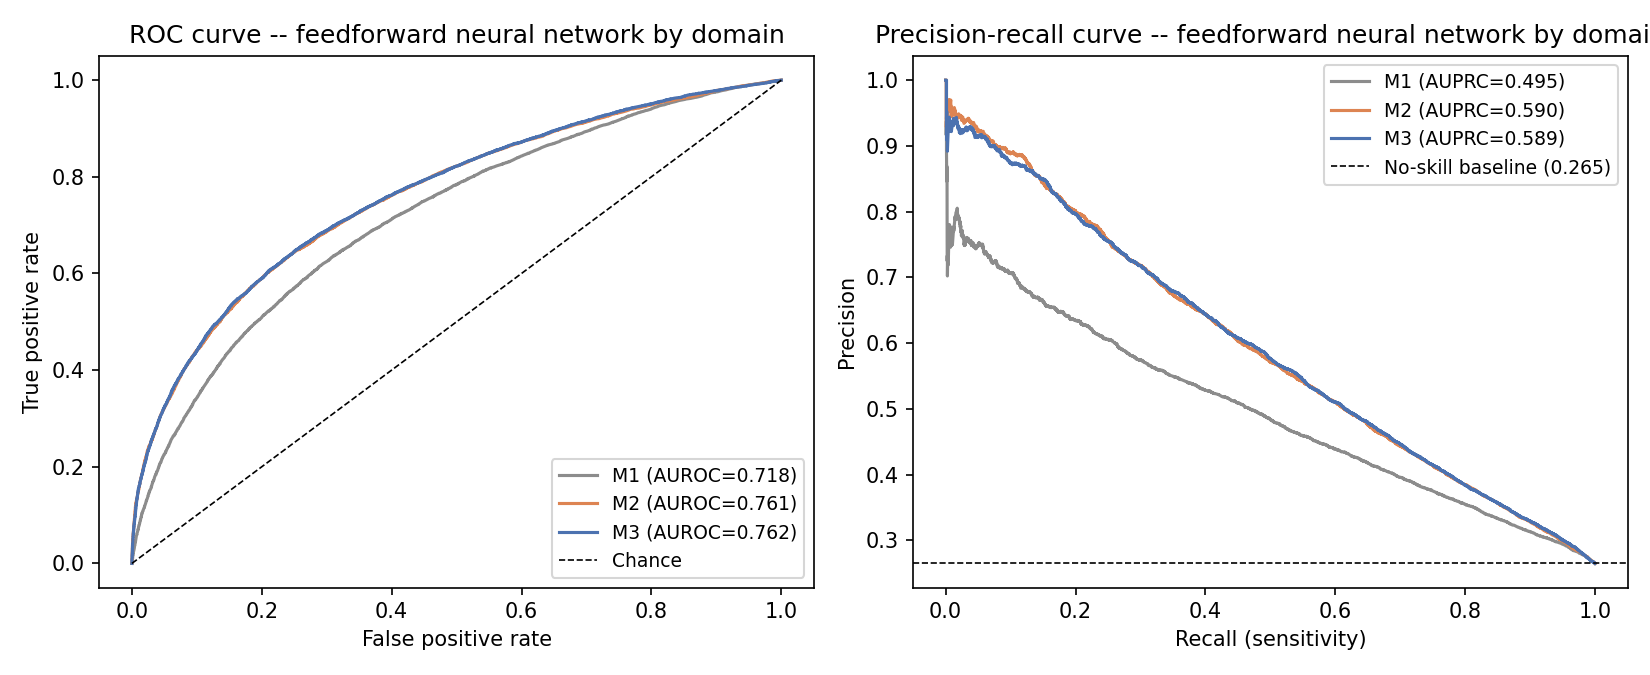

In [48]:
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
colors = {"M1": "#8C8C8C", "M2": "#DD8452", "M3": "#4C72B0"}

for domain_name in ["M1", "M2", "M3"]:
    proba = ffnn_test_probas[domain_name]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auroc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, color=colors[domain_name], label=f"{domain_name} (AUROC={auroc:.3f})")

    precision, recall, _ = precision_recall_curve(y_test, proba)
    auprc = average_precision_score(y_test, proba)
    axes[1].plot(recall, precision, color=colors[domain_name], label=f"{domain_name} (AUPRC={auprc:.3f})")

axes[0].plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=0.8, label="Chance")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC curve -- feedforward neural network by domain")
axes[0].legend(loc="lower right", fontsize=9)

axes[1].axhline(y_test.mean(), linestyle="--", color="black", linewidth=0.8,
                label=f"No-skill baseline ({y_test.mean():.3f})")
axes[1].set_xlabel("Recall (sensitivity)")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-recall curve -- feedforward neural network by domain")
axes[1].legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig18_ffnn_roc_pr_curves.png", dpi=150)
plt.show()

## Analysis of factors

A network's weights don't reduce to per-predictor coefficients the way a linear model's do --
even with one hidden layer, a feature's effect is mediated through every hidden unit it feeds
into, so "the weight on this input" isn't a meaningful summary the way an odds ratio is. Same
approach as the two tree models, for comparability: permutation importance on the fitted M3
pipeline, computed on a random 15,000-row test subsample with 5 repeats per feature.

In [49]:
ffnn_m3_pipeline = MODEL_REGISTRY["ffnn_M3"]["pipeline"]

rng = np.random.RandomState(RANDOM_SEED)
perm_sample_idx = rng.choice(X_test.index, size=15_000, replace=False)

perm_result = permutation_importance(
    ffnn_m3_pipeline, X_test.loc[perm_sample_idx, M3_FEATURES], y_test.loc[perm_sample_idx],
    n_repeats=5, random_state=RANDOM_SEED, scoring="roc_auc", n_jobs=-1,
)

ffnn_perm_importance_table = pd.DataFrame({
    "feature": M3_FEATURES,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std,
}).sort_values("importance_mean", ascending=False)
ffnn_perm_importance_table.to_csv(MODEL_DIR / "ffnn_permutation_importance.csv", index=False)
ffnn_perm_importance_table.round(4)

              feature  importance_mean  importance_std
0           age_group           0.0706          0.0030
11    checkup_recency           0.0414          0.0010
5   employment_status           0.0106          0.0017
4        income_group           0.0093          0.0007
9     personal_doctor           0.0086          0.0007
3     education_level           0.0083          0.0013
6      marital_status           0.0052          0.0004
2      race_ethnicity           0.0037          0.0006
8    insurance_status           0.0033          0.0010
15     smoking_status           0.0028          0.0005
7         urban_rural           0.0023          0.0002
16       bmi_category           0.0023          0.0005
10       cost_barrier           0.0022          0.0007
14      heart_disease           0.0014          0.0005
1                 sex           0.0012          0.0003
13    diabetes_status           0.0012          0.0001
12     general_health           0.0007          0.0003

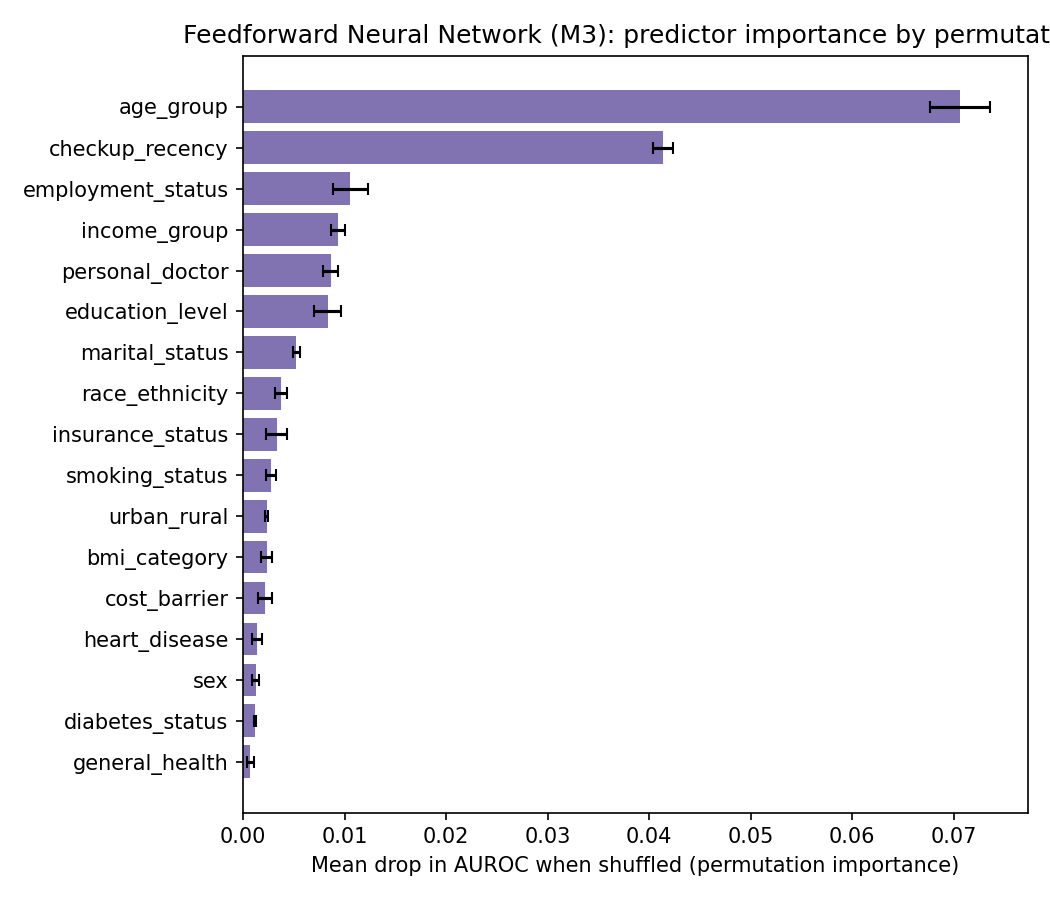

In [50]:
fig, ax = plt.subplots(figsize=(7, 6))
plot_order = ffnn_perm_importance_table.sort_values("importance_mean")
ax.barh(
    plot_order["feature"], plot_order["importance_mean"],
    xerr=plot_order["importance_std"], color="#8172B2", capsize=3,
)
ax.set_xlabel("Mean drop in AUROC when shuffled (permutation importance)")
ax.set_title("Feedforward Neural Network (M3): predictor importance by permutation")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig19_ffnn_permutation_importance.png", dpi=150)
plt.show()

**Reading the chart:** the same two predictors lead as in both tree models -- `age_group`
(~0.071 mean AUROC drop) and `checkup_recency` (~0.041) -- with `employment_status`,
`income_group`, `personal_doctor` and `education_level` forming a consistent secondary tier. All
three non-linear models (random forest, gradient boosting, feedforward network) agree on this
ranking far more than any of them agrees with the logistic regression odds ratios on relative
magnitude, which is the same age-gradient story discussed above: a model that can represent
non-linear relationships directly picks up on `age_group`'s importance in a way one linear
coefficient can't.

### Hyperparameter search

Same pattern as the two tree models' searches: `RandomizedSearchCV`, 10 parameter combinations,
3-fold stratified CV, scored on AUROC, run on the same 40,000-row training subsample for runtime
reasons. Search space covers network capacity (`hidden_layer_sizes`, from a single 32-unit layer
up to a three-layer 100-50-25 network), `alpha` (L2 regularisation), `learning_rate_init`, and
`activation` (`relu` vs `tanh`) -- the parameters most likely to trade off underfitting against
overfitting for a network this size. Done within the training fold only, consistent with the
calibration-vs-validation distinction from notebook 3.

In [51]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

search_sample_idx = np.random.RandomState(RANDOM_SEED).choice(X_train.index, size=40_000, replace=False)
X_search = X_train.loc[search_sample_idx, M3_FEATURES]
y_search = y_train.loc[search_sample_idx]
w_search = compute_sample_weight("balanced", y_search)

ffnn_search_pipe = build_ffnn_pipeline(M3_FEATURES)
ffnn_param_distributions = {
    "model__hidden_layer_sizes": [(32,), (64,), (64, 32), (128, 64), (100, 50, 25)],
    "model__alpha": [1e-5, 1e-4, 1e-3, 1e-2],
    "model__learning_rate_init": [1e-4, 1e-3, 1e-2],
    "model__activation": ["relu", "tanh"],
}

ffnn_search = RandomizedSearchCV(
    ffnn_search_pipe, ffnn_param_distributions, n_iter=10,
    cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_SEED),
    scoring="roc_auc", random_state=RANDOM_SEED, n_jobs=1,
)
ffnn_search.fit(X_search, y_search, model__sample_weight=w_search)

print("Best parameters found:", ffnn_search.best_params_)
print(f"Best CV AUROC (on the 40k search subsample): {ffnn_search.best_score_:.4f}")

Best parameters found: {'model__learning_rate_init': 0.01, 'model__hidden_layer_sizes': (128, 64), 'model__alpha': 0.0001, 'model__activation': 'relu'}
Best CV AUROC (on the 40k search subsample): 0.7540

In [52]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neural_network import MLPClassifier

best_ffnn_params = {
    k.replace("model__", ""): v for k, v in ffnn_search.best_params_.items()
}

ffnn_tuned_pipe = Pipeline([
    ("preprocess", ColumnTransformer([
        ("ordinal", OrdinalRankWithMissingFlag(
            {c: ORDINAL_CATEGORY_ORDER[c] for c in ordinal_subset(M3_FEATURES)}
        ), ordinal_subset(M3_FEATURES)),
        ("nominal", OneHotEncoder(handle_unknown="ignore"), nominal_subset(M3_FEATURES)),
    ])),
    ("scale", StandardScaler(with_mean=False)),
    ("model", MLPClassifier(
        early_stopping=True, random_state=RANDOM_SEED, **best_ffnn_params,
    )),
])
ffnn_tuned_pipe.fit(X_train[M3_FEATURES], y_train, model__sample_weight=w_train)

proba_ffnn_tuned = ffnn_tuned_pipe.predict_proba(X_test[M3_FEATURES])[:, 1]
pred_ffnn_tuned = (proba_ffnn_tuned >= 0.5).astype(int)
ffnn_tuned_metrics = {
    "AUROC": roc_auc_score(y_test, proba_ffnn_tuned),
    "AUPRC": average_precision_score(y_test, proba_ffnn_tuned),
    "Precision": precision_score(y_test, pred_ffnn_tuned),
    "Sensitivity": recall_score(y_test, pred_ffnn_tuned),
    "F1": f1_score(y_test, pred_ffnn_tuned),
    "Accuracy": accuracy_score(y_test, pred_ffnn_tuned),
}

register_model(
    name="ffnn_M3_tuned", pipeline=ffnn_tuned_pipe, metrics=ffnn_tuned_metrics, features=M3_FEATURES,
    model_type="Feedforward Neural Network (class-weighted, RandomizedSearchCV-tuned)",
    notes=(f"{best_ffnn_params} -- from a 10-iter/cv=3 RandomizedSearchCV on a 40k-row training subsample."),
)

ffnn_comparison = pd.DataFrame([
    {"Model": "ffnn_M3 (default)", **MODEL_REGISTRY["ffnn_M3"]["metrics"]},
    {"Model": "ffnn_M3_tuned (searched)", **ffnn_tuned_metrics},
])
ffnn_comparison.round(4)

                     Model   AUROC   AUPRC  Precision  Sensitivity      F1  Accuracy
0        ffnn_M3 (default)  0.7623  0.5893     0.4941       0.6231  0.5512    0.7313
1  ffnn_M3_tuned (searched)  0.7638  0.5910     0.4706       0.6661  0.5516    0.7132

**Reading this comparison:** the search preferred a larger network (128, 64 hidden units, vs.
the 64, 32 default) with a higher learning rate (0.01 vs. the default 0.001) and the same ReLU
activation and light L2 regularisation. Test AUROC improves modestly, 0.7623 -> 0.7638 -- the
same small-but-real "tuning helps a little" pattern seen with gradient boosting, and larger than
random forest's near-tie. Worth flagging rather than glossing over: the tuned model's precision
drops (0.494 -> 0.471) while sensitivity rises noticeably (0.623 -> 0.666) at the default 0.5
threshold -- a real precision/recall trade-off from the larger, higher-learning-rate network, not
just noise, and a reminder that "AUROC went up" doesn't automatically mean every operating-point
metric moves the same direction. `ffnn_M3_tuned` is registered alongside everything else and
included in the model comparison below.

# Model comparison

Every model fit above -- three domains (M1/M2/M3) x three families (logistic regression, random
forest, gradient boosting), plus the tuned random forest -- is sitting in `MODEL_REGISTRY` and
logged in `model_registry_manifest.csv`. This section pulls them together into one table rather
than leaving the comparison scattered across the sections above.

In [53]:
comparison_table = (
    pd.DataFrame([
        {"name": name, "model_type": entry["model_type"], "n_features": len(entry["features"]), **entry["metrics"]}
        for name, entry in MODEL_REGISTRY.items()
    ])
    .sort_values("AUROC", ascending=False)
    .reset_index(drop=True)
)
comparison_table.to_csv(MODEL_DIR / "model_comparison_table.csv", index=False)
comparison_table.round(4)

         name                                                                  model_type  n_features   AUROC   AUPRC  Precision  Sensitivity      F1  Accuracy
0   gb_M3_tuned                Gradient Boosting (class-weighted, RandomizedSearchCV-tuned)          17  0.7662  0.5974     0.4910       0.6385  0.5551    0.7291
1         gb_M3 Gradient Boosting (class-weighted, HistGradientBoostingClassifier defaults)          17  0.7659  0.5970     0.4888       0.6364  0.5529    0.7275
2 ffnn_M3_tuned      Feedforward Neural Network (class-weighted, RandomizedSearchCV-tuned)          17  0.7638  0.5910     0.4706       0.6661  0.5516    0.7132
3         gb_M2 Gradient Boosting (class-weighted, HistGradientBoostingClassifier defaults)          12  0.7636  0.5940     0.4878       0.6378  0.5528    0.7268
4       ffnn_M3 Feedforward Neural Network (class-weighted, MLPClassifier, hidden=(64,32))          17  0.7623  0.5893     0.4941       0.6231  0.5512    0.7313
5   rf_M3_tuned                 

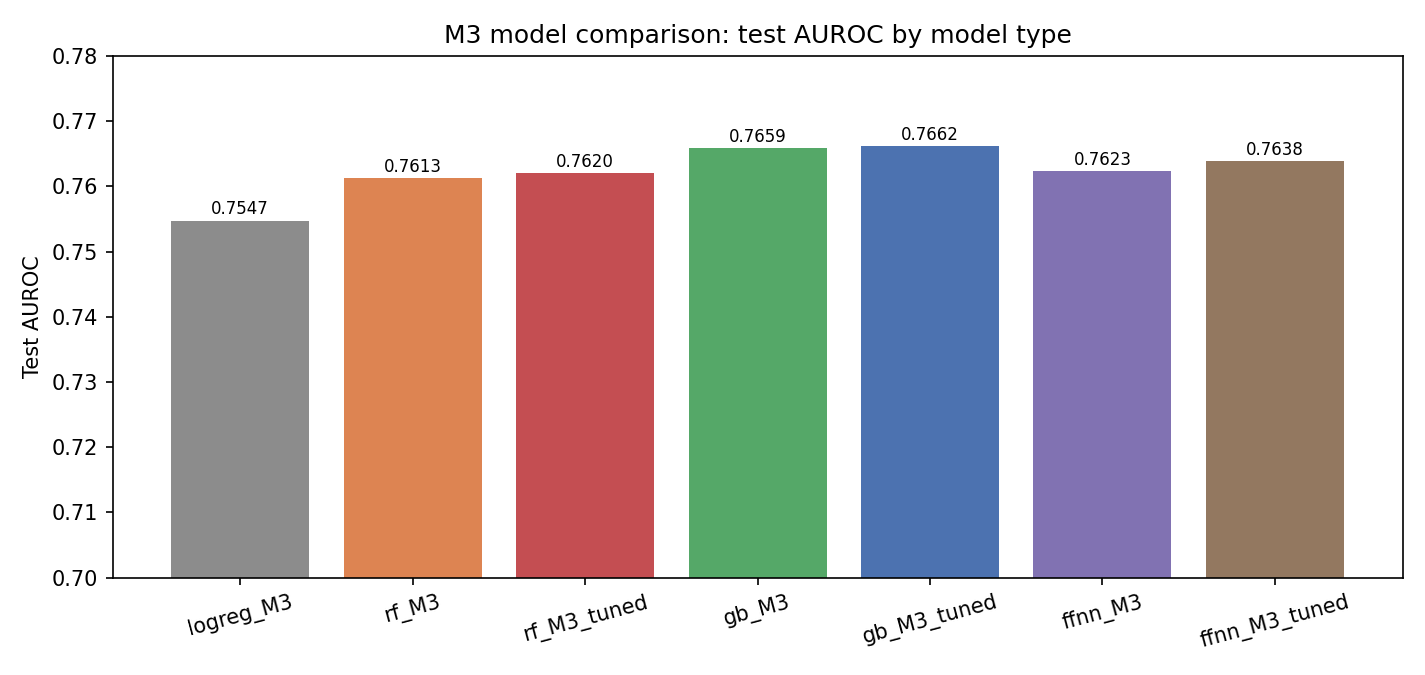

In [54]:
m3_models = comparison_table[comparison_table["name"].isin(["logreg_M3", "rf_M3", "rf_M3_tuned", "gb_M3", "gb_M3_tuned", "ffnn_M3", "ffnn_M3_tuned"])].copy()
order = ["logreg_M3", "rf_M3", "rf_M3_tuned", "gb_M3", "gb_M3_tuned", "ffnn_M3", "ffnn_M3_tuned"]
m3_models["name"] = pd.Categorical(m3_models["name"], categories=order, ordered=True)
m3_models = m3_models.sort_values("name")

fig, ax = plt.subplots(figsize=(9.5, 4.5))
colors_bar = ["#8C8C8C", "#DD8452", "#C44E52", "#55A868", "#4C72B0", "#8172B2", "#937860"]
bars = ax.bar(m3_models["name"], m3_models["AUROC"], color=colors_bar)
ax.set_ylim(0.7, 0.78)
ax.set_ylabel("Test AUROC")
ax.set_title("M3 model comparison: test AUROC by model type")
ax.tick_params(axis="x", labelrotation=15)
for bar, val in zip(bars, m3_models["AUROC"]):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.001, f"{val:.4f}", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig17_model_comparison_auroc.png", dpi=150)
plt.show()

**Reading the comparison:**

Two patterns hold consistently across all four model families now: adding predictor domains
always helps (M1 -> M2 -> M3 improves AUROC every time, though the M2 -> M3 step is small -- most
of the lift comes from adding access-to-care variables in M2, with the M3 health variables adding
little on top), and the non-linear models (random forest, gradient boosting, feedforward network)
all comfortably beat logistic regression, with gradient boosting narrowly ahead of the other two.

**Gradient boosting (M3, tuned) remains the best-performing model overall** at test AUROC 0.7662,
just ahead of the untuned gradient boosting default (0.7659). The feedforward network's tuned
variant (0.7638) lands between the two gradient boosting models and the two random forest models
(0.7613-0.7620) -- a genuinely competitive result for a fourth model added beyond the original
proposal, and further evidence that this dataset's signal is dominated by a handful of strong,
somewhat non-linear predictors (age and recent-checkup history) that any reasonably-capable
non-linear model can extract, rather than by a lot of easily-missed complexity.

**Hyperparameter search moved the needle by different amounts for each model.** Random forest
was essentially a tie (0.7613 -> 0.7620); gradient boosting also barely moved (0.7659 -> 0.7662);
the feedforward network showed the largest -- still modest -- gain (0.7623 -> 0.7638), and unlike
the other two, its tuning came with a visible precision/recall trade-off (sensitivity up from
0.623 to 0.666, precision down from 0.494 to 0.471) rather than a clean win across every metric.
Switching model *family* mattered more for AUROC than tuning *within* a family for every model
tried so far, which is a reasonable prior for where to spend further effort -- calibration,
threshold selection, and subgroup performance are likely to matter more for the final deliverable
than a larger search.

**Accuracy leaders vs. interpretability model of record are different models, and that's expected,
not a problem.** All three non-linear models outperform logistic regression on ranking metrics,
but none of them has coefficients -- their "Analysis of factors" sections all rely on permutation
importance, which explains *how much* a predictor matters to the model's predictions but not the
*direction and per-category size* of its association with non-compliance the way an odds ratio
does. Per the project proposal, logistic regression remains the interpretability model of record
(the odds-ratio table and forest plot above); gradient boosting (tuned) is the candidate for the
leading model if the deliverable prioritises predictive performance for targeting outreach. All
three non-linear models' permutation-importance rankings agree with each other far more than they
agree with the logistic regression odds ratios on relative magnitude -- particularly `age_group`,
whose non-linear relationship with non-compliance (see the EDA notebook) a non-linear model can
exploit directly in a way one linear coefficient understates. That's a real, worth-reporting
distinction between what "important" means under each model, not a contradiction to be resolved.

**Still deferred**, per notebook 3's handoff notes and unaffected by which model leads: real
geographic-fold evaluation, calibration and the risk-decile table, and subgroup/equity
performance reporting on whichever model is carried forward.